# Imports

In [11]:
import numpy as np
from sympy import *

import sys
from pathlib import Path

# Notebook cwd: .../FV-Controls/Maurice2/tests
PROJECT_DIR = Path.cwd().parents[2]       # -> .../FV-Controls
SRC_DIR = PROJECT_DIR / "src"             # -> .../FV-Controls/src
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

%load_ext autoreload
%autoreload 2

import dynamics.dynamics as dynamics
import controls.controls as controls
import simulation.simulation as simulation

from dynamics.dynamics import Dynamics
from controls.controls import Controls
from simulation.simulation import Simulation


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create a rocket

In [12]:
rocket_name = "Maurice 2"
dynamics = Dynamics(rocket_name=rocket_name)

# Get thrust curve

In [13]:
thrust_csv = "/Users/dsong/Library/CloudStorage/OneDrive-UniversityofIllinois-Urbana/Courses/25-26/Fall 2025/AE 370/370 Projects/370 Project 1/370 GP1/data/openrocket_data.csv"
thrust_eng = "/Users/dsong/Library/CloudStorage/OneDrive-UniversityofIllinois-Urbana/Courses/25-26/Fall 2025/AE 370/370 Projects/370 Project 1/370 GP1/data/AeroTech_HP-I280DM.eng"

dynamics.printThrustCurve(thrust_file=thrust_csv)
# Alternatively, with .eng file:
# controls.printThrustCurve(thrust_file=thrust_eng)

thrust_times = np.array([0.0, 0.01, 0.016, 0.025, 0.035, 0.045, 0.048, 0.052, 0.059, 0.069, 0.079, 0.089, 0.099, 0.111, 0.121, 0.13, 0.139, 0.147, 0.154, 0.165, 0.173, 0.185, 0.202, 0.228, 0.261, 0.294, 0.323, 0.334, 0.35, 0.374, 0.404, 0.438, 0.481, 0.498, 0.524, 0.563, 0.602, 0.623, 0.641, 0.658, 0.673, 0.687, 0.701, 0.705, 0.711, 0.721, 0.734, 0.747, 0.761, 0.775, 0.791, 0.802, 0.818, 0.842, 0.878, 0.902, 0.919, 0.933, 0.945, 0.957, 0.967, 0.978, 0.988, 1.0, 1.011, 1.022, 1.025, 1.03, 1.036, 1.047, 1.057, 1.073, 1.096, 1.1, 1.106, 1.115, 1.128, 1.139, 1.15, 1.16, 1.169, 1.178, 1.188, 1.197, 1.205, 1.216, 1.228, 1.244, 1.267, 1.298, 1.311, 1.322, 1.332, 1.336, 1.342, 1.352, 1.361, 1.371, 1.383, 1.397, 1.4, 1.405, 1.413, 1.424, 1.441, 1.462, 1.474, 1.484, 1.494, 1.5, 1.509, 1.52, 1.533, 1.55, 1.576, 1.595, 1.608, 1.619, 1.629, 1.634, 1.641, 1.652, 1.664, 1.681, 1.707, 1.716, 1.73, 1.743, 1.754, 1.765, 1.776, 1.789, 1.8, 1.817, 1.842, 1.856, 1.867, 1.878, 1.89, 1.9, 1.915, 1.938, 1.97,

# Configure rocket dynamics parameters

In [14]:
def config_dynamics(dynamics: Dynamics):
    thrust_times = np.array([0.0, 0.01, 0.016, 0.025, 0.035, 0.045, 0.048, 0.052, 0.059, 0.069, 0.079, 0.089, 0.099, 0.111, 0.121, 0.13, 0.139, 0.147, 0.154, 0.165, 0.173, 0.185, 0.202, 0.228, 0.261, 0.294, 0.323, 0.334, 0.35, 0.374, 0.404, 0.438, 0.481, 0.498, 0.524, 0.563, 0.602, 0.623, 0.641, 0.658, 0.673, 0.687, 0.701, 0.705, 0.711, 0.721, 0.734, 0.747, 0.761, 0.775, 0.791, 0.802, 0.818, 0.842, 0.878, 0.902, 0.919, 0.933, 0.945, 0.957, 0.967, 0.978, 0.988, 1.0, 1.011, 1.022, 1.025, 1.03, 1.036, 1.047, 1.057, 1.073, 1.096, 1.1, 1.106, 1.115, 1.128, 1.139, 1.15, 1.16, 1.169, 1.178, 1.188, 1.197, 1.205, 1.216, 1.228, 1.244, 1.267, 1.298, 1.311, 1.322, 1.332, 1.336, 1.342, 1.352, 1.361, 1.371, 1.383, 1.397, 1.4, 1.405, 1.413, 1.424, 1.441, 1.462, 1.474, 1.484, 1.494, 1.5, 1.509, 1.52, 1.533, 1.55, 1.576, 1.595, 1.608, 1.619, 1.629, 1.634, 1.641, 1.652, 1.664, 1.681, 1.707, 1.716, 1.73, 1.743, 1.754, 1.765, 1.776, 1.789, 1.8, 1.817, 1.842, 1.856, 1.867, 1.878, 1.89, 1.9, 1.915, 1.938, 1.97, 1.973])
    thrust_forces = np.array([0.0, 213.993, 342.389, 329.629, 315.452, 301.274, 297.021, 298.388, 300.439, 303.477, 306.515, 309.552, 312.59, 316.16, 318.104, 319.884, 321.527, 323.061, 324.504, 326.669, 328.211, 327.92, 327.502, 325.345, 322.54, 317.697, 313.449, 311.907, 311.77, 311.564, 311.299, 311.007, 310.638, 310.489, 309.961, 309.17, 308.363, 308.217, 308.092, 307.979, 307.874, 307.777, 307.683, 307.654, 307.84, 308.12, 308.499, 308.883, 309.28, 309.704, 310.176, 310.489, 310.489, 310.489, 310.489, 310.489, 309.747, 309.148, 308.616, 308.121, 307.652, 307.202, 306.759, 306.236, 310.754, 315.582, 316.869, 315.763, 314.103, 311.614, 309.072, 308.814, 308.427, 308.363, 309.739, 311.802, 314.897, 317.578, 315.946, 314.451, 313.031, 311.64, 310.244, 308.805, 307.654, 307.24, 306.771, 306.185, 305.306, 304.109, 308.325, 311.736, 314.828, 316.16, 314.555, 312.207, 309.788, 307.212, 304.314, 300.719, 299.856, 299.676, 299.406, 299.001, 298.393, 297.67, 297.241, 296.871, 296.522, 296.312, 296.69, 297.151, 297.701, 298.438, 303.352, 306.945, 303.019, 299.855, 296.971, 295.603, 289.769, 280.716, 275.556, 268.18, 257.116, 253.07, 237.948, 224.006, 210.77, 197.444, 183.599, 167.68, 153.827, 138.394, 115.244, 102.974, 92.801, 82.688, 71.644, 62.381, 53.303, 39.686, 20.558, 0.0])
    dynamics.setThrustCurve(thrust_times=thrust_times, thrust_forces=thrust_forces)
    
    xhat0 = np.array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0]) # Initial state estimate
    sampling_rate = 40.0  # Hz
    dt = 1.0 / sampling_rate
    dynamics.setSimParams(dt=dt, x0=xhat0)
    
    def SM_func(burnout: bool, AoA_deg: Expr):
        if not burnout:
            return 2.8 + -0.48*AoA_deg + 0.163*AoA_deg**2 + -0.0386*AoA_deg**3 + \
                5.46E-03*AoA_deg**4 + -4.61E-04*AoA_deg**5 + 2.28E-05*AoA_deg**6 + \
                -6.1E-07*AoA_deg**7 + 6.79E-09*AoA_deg**8
        else:
            return -0.086*AoA_deg + 2.73

    dynamics.setRocketParams(
        I_0=0.327,
        I_f=0.287,
        I_3=0.0035,
        x_CG_0=0.675,
        x_CG_f=0.635,
        m_0=2.944,
        m_f=2.589,
        m_p=0.355,
        d=0.0787,
        L_ne=1.17,
        C_d=0.6099051282,
        Cnalpha_rocket=0.207,
        t_launch_rail_clearance=0.308,
        t_motor_burnout=1.971,
        t_estimated_apogee=13.571,
        SM_func=SM_func
    )
    dynamics.setFinParams(
        N=4,
        Cr=0.18,
        Ct=0.0597,
        s=0.0876,
        Cnalpha_fin=2.72025,
        delta=0.1
    )
    
    return dynamics

# Configure rocket controls/sensors parameters

In [15]:
def config_controls(controls: Controls):
    controls = config_dynamics(controls)


    def M_controls_func(state, input) -> Matrix:
        w1, w2, w3, v1, v2, v3, qw, qx, qy, qz = state
        zeta = input[0]
        
        M1, M2 = 0, 0
        # -8.26e-05 + 4.18e-06x + 1.58e-06x^2 + -2.21e-09x^3
        M3 = 4*deg(zeta)/8 * (-2.21e-09*(v3**3) 
                        + 1.58e-06*(v3**2) 
                        + 4.18e-06*v3
                        )
        return Matrix([M1, M2, M3])
    
    controls.add_control_surface_moments(M_controls_func=M_controls_func)
    controls.setup_eom()


    u0 = np.array([0.0])  # Initial control input (aileron angle in radians)
    max_input = np.deg2rad(8) # Maximum aileron angle in radians
    controls.set_controls_params(u0=u0, max_input=max_input)
    

    def K(t: float, xhat: np.array) -> np.ndarray:
        """Compute the control input based on the current state estimate and gain matrix.

        Args:
            t (float): The current time in seconds.
            xhat (np.array): The estimated state vector.
        Returns:
            np.ndarray: The computed gain matrix K.
        """
        w1, w2, w3, v1, v2, v3, qw, qx, qy, qz = xhat
        K = np.zeros((1, 10))
        K_val = 1.0e-1
        if t < controls.t_launch_rail_clearance:
            K_val = 0.0
        # if (t < controls.t_motor_burnout):
        #     Kmax = 2.0e-1
        #     Kmin = 1.0e-2
        #     pre_v3_mid = 80
        #     pre_transition_width = 10
        #     K_val = Kmin + (Kmax - Kmin) / (1 + exp((w3 - pre_v3_mid)/pre_transition_width))

        # # Postburnout
        # else:
        #     Kmax = 1.0e-1
        #     Kmin = 1.0e-2
        #     # v3_mid = 80 # m/s, tune as necessary hiii dan :3
        #     post_v3_mid = 60
        #     post_transition_width = 10
        #     K_val = Kmin + (Kmax - Kmin) / (1 + exp((w3 - post_v3_mid)/post_transition_width))

        K[0][2] = K_val

        return K
    
    controls.setK(K=K)
    

    def buildL(lw=1.0, lqw=1.0, lqx=1.0, lqy=1.0, lqz=1.0):
        """
        Hand-tuned observer gain L (10x7) for x=[v(3), w(3), q(4)], y=[w(3), q(4)].
        - Only w3 row uses the w3 residual.
        - Quaternion rows use quaternion residuals; roll-weight lqz can be larger.
        - All velocity rows are zero to avoid injecting measurement noise into v.

        Args:
            lw (float): Gain for w residual into w states.
            lqw (float): Gain for qw residual into qw state.
            lqx (float): Gain for qx residual into qx state.
            lqy (float): Gain for qy residual into qy state.
            lqz (float): Gain for qz residual into qz state.

        Returns:
            np.ndarray: The observer gain matrix L.
        """
        L = np.zeros((10, 7))

        L[0, 0] = lw # w1
        L[1, 1] = lw # w2
        L[2, 2] = lw # w3

        # quaternion <- r_quaternion
        L[6, 3] = lqw   # qw residual into qw state
        L[7, 4] = lqx   # qx residual into qx state
        L[8, 5] = lqy   # qy residual into qy state
        L[9, 6] = lqz   # qz residual into qz state (roll-heavy)

        return L

    lw, lq = 1e-3, 1e-3
    L = buildL(lw=lw, lqw=lq, lqx=lq, lqy=lq, lqz=lq)
    controls.setL(L=L)


    def sensor_model(t: float, xhat: np.array) -> np.array:
        """Derive the sensor models for the rocket. Assumes small angles for accelerometer bias calculation. Converts Euler angles to quaternion.

        Args:
            t (float): The time in seconds.
            w1 (float): The angular velocity in the x direction in rad/s.
            w2 (float): The angular velocity in the y direction in rad/s.
            w3 (float): The angular velocity in the z direction in rad/s.
            theta (float): The pitch angle in radians.
            phi (float): The yaw angle in radians.
            psi (float): The roll angle in radians.

        Returns:
            np.array: The sensor measurements as a numpy array. [gx, gy, gz, qw, qx, qy, qz]. Gyro in rad/s, quaternion normalized.
        """
        w1, w2, w3, qw, qx, qy, qz = xhat[0], xhat[1], xhat[2], xhat[6], xhat[7], xhat[8], xhat[9]
        q = np.array([qw, qx, qy, qz])
        theta, phi, psi = dynamics.quat_to_euler_xyz(q)
        
        bg1 = np.deg2rad(20.116124137171195 / 3600) # rad/s
        bg2 = np.deg2rad(28.34293605241209 / 3600) # rad/s
        bg3 = np.deg2rad(25.387227350679243 / 3600) # rad/s

        ARW1 = np.deg2rad(6.6977525311882316 / 60) # rad/sqrt(s)
        ARW2 = np.deg2rad(7.733730273458847 / 60) # rad/sqrt(s)
        ARW3 = np.deg2rad(7.020108147288731 / 60) # rad/sqrt(s)

        sigma_w1 = ARW1 / np.sqrt(dynamics.dt)
        sigma_w2 = ARW2 / np.sqrt(dynamics.dt)
        sigma_w3 = ARW3 / np.sqrt(dynamics.dt)

        gw1 = w1 + bg1 + np.random.normal(0.0, sigma_w1)
        gw2 = w2 + bg2 + np.random.normal(0.0, sigma_w2)
        gw3 = w3 + bg3 + np.random.normal(0.0, sigma_w3)

        sigma_theta = np.deg2rad(0.9840317663439204 / (60)) / np.sqrt(dynamics.dt) # rad
        sigma_phi = np.deg2rad(0.872408877638351 / (60)) / np.sqrt(dynamics.dt) # rad

        sigma_Bx = 0.006669083462481435
        sigma_By = 0.003656134366885892
        Bx = 3.500
        By = 28.500
        sigma_psi = np.sqrt((sigma_Bx * By)**2 + (sigma_By * Bx)**2) / (Bx**2 + By**2)

        b_theta = (287.9041401059671 / (9.81 * 3600)) # rad/s (small-angle a_x/g)
        b_phi = (88.37148088944824 / (9.81 * 3600)) # rad/s (small-angle a_y/g)

        bx = 1.5945108844195712
        by = 0.8536236163450057
        b_psi = np.sqrt((bx * By)**2 + (by * Bx)**2) / (Bx**2 + By**2) / 3600 # rad/s?

        theta_m = theta + b_theta * t + np.random.normal(0.0, sigma_theta)
        phi_m = phi + b_phi * t + np.random.normal(0.0, sigma_phi)
        psi_m = psi + b_psi * t + np.random.normal(0.0, sigma_psi)

        q = dynamics.euler_to_quat_xyz(theta_m, phi_m, psi_m)

        y = np.array([gw1, gw2, gw3, q[0], q[1], q[2], q[3]])

        return y
    
    w1, w2, w3, v1, v2, v3, qw, qx, qy, qz = controls.state_vars
    sensor_vars = [w1, w2, w3, qw, qx, qy, qz]
    controls.set_sensor_params(sensor_vars=sensor_vars, sensor_model=sensor_model)
    
    return controls

# Create fully configured Controls() object

In [16]:
IREC_COMPLIANT = False
controls = Controls(IREC_COMPLIANT=IREC_COMPLIANT, dynamics=dynamics)
controls = config_controls(controls)

# Create Simulation() object

In [17]:
simulation = Simulation()
simulation.set_controls(controls)
simulation.disable_sensors = True
simulation.disable_controls = False
file_name = "test_controls_simulation"

# Run controls simulation

In [18]:
simulation.run_controls_simulation(file_name=file_name, log_controls_moments=True)

Controls ■■■■■■■■■■■■■■■■■■■■■■■■■□□□□□  81.8%  t =  11.10/13.57 s
Controls data saved to: /Users/dsong/Library/CloudStorage/OneDrive-UniversityofIllinois-Urbana/Club Stuff/LRI/FV-Controls/rockets/Maurice 2/data/sim_output/controls/test_controls_simulation.csv


# Plot controls simulation results

Using controls data from test_controls_simulation.csv for plotting.


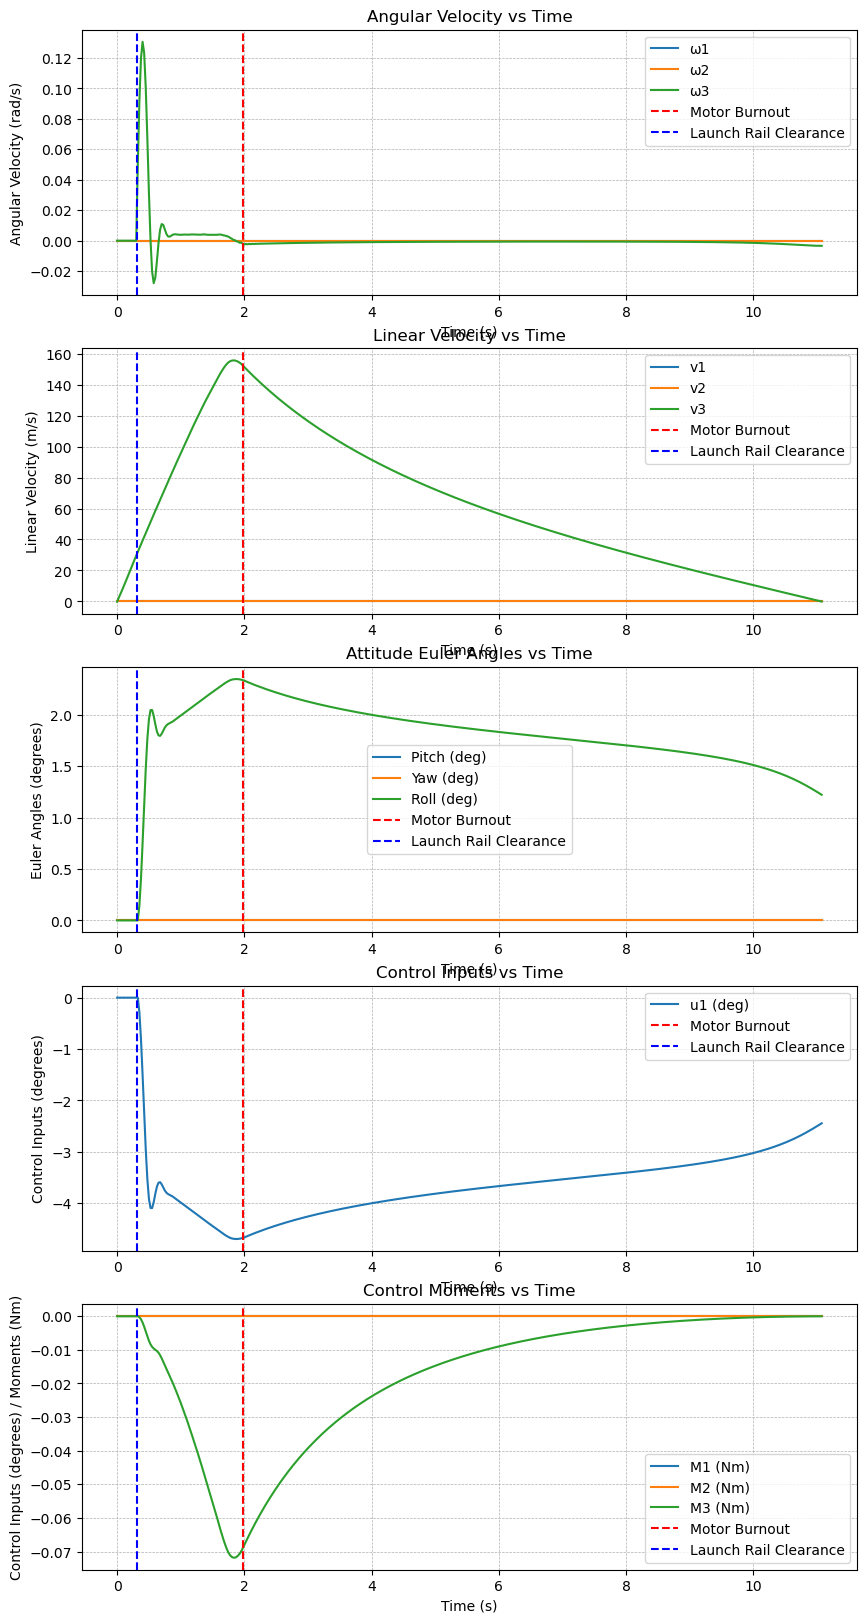

In [19]:
fig, axs = simulation.plot_controls(file_name=file_name, control_moments=True)

# Plot controls vs dynamics comparison

In [2]:
simulation.set_dynamics(dynamics=dynamics)
fig, axs = simulation.compare_controls_dynamics(controls_file_name="test_controls_simulation", dyanmics_file_name="test_dynamics_simulation")

NameError: name 'simulation' is not defined